## LoL Champ-Select EDA & Model Evaluation

Dieses Notebook erstellt:
- **Champion Winrates pro Rolle** (aus meinem Dataset von Master+ Spielern, aus allen Regionen (und das gleich verteilt))
- **Modell-Evaluation** (Confusion Matrix, Classification Reports und Feature Importance)

**Datasets:**
- **Champion Winrates:** `59334_filtered_augmented_dataset.csv` (Basis-Dataset)
- **Modell-Evaluation:** Priorisiert `59334_champselect_features.csv` (reichstes Dataset mit allen Features), Fallback: `59334_with_winrates.csv`

**Hinweis:** 
- **Bans und Gamelength werden nicht verwendet** und sind daher aus allen Analysen ausgeschlossen.



In [61]:
from __future__ import annotations

from pathlib import Path
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import joblib

sns.set_theme(style="whitegrid")

PROJECT_ROOT = Path.cwd().parent if (Path.cwd().name == "notebooks") else Path.cwd()
DATA_DIR = PROJECT_ROOT / "data" / "datasets"
MODELS_DIR = PROJECT_ROOT / "models"
REPORTS_DIR = PROJECT_ROOT / "reports"
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

RAW_DATASET = DATA_DIR / "59334_filtered_augmented_dataset.csv"
WINRATES_DATASET = DATA_DIR / "59334_with_winrates.csv"
CHAMPSELECT_DATASET = DATA_DIR / "59334_champselect_features.csv"

POSITIONS = ["top", "jungle", "mid", "adc", "support"]

print("PROJECT_ROOT:", PROJECT_ROOT)
print("RAW_DATASET exists:", RAW_DATASET.exists())
print("WINRATES_DATASET exists:", WINRATES_DATASET.exists())
print("CHAMPSELECT_DATASET exists:", CHAMPSELECT_DATASET.exists())


PROJECT_ROOT: c:\Users\Alexander\lol-winrate-prediction
RAW_DATASET exists: True
WINRATES_DATASET exists: True
CHAMPSELECT_DATASET exists: True


In [62]:
# Lade Dataset für Champion Winrate-Berechnung
# WICHTIG: df_raw wird später verwendet für:
# - compute_role_champion_stats(df_raw) → berechnet Winrates pro Champion/Rolle
df_raw = pd.read_csv(RAW_DATASET)
print("Dataset geladen:", len(df_raw), "Matches,", len(df_raw.columns), "Spalten")


Dataset geladen: 59334 Matches, 29 Spalten


## Champion Winrates pro Rolle (aus den Matches)

**Wie werden die Winrates berechnet?**

Die Funktion `compute_role_champion_stats()` liest folgende Werte aus dem Dataset:

1. **Ausgelesene Spalten:**
   - `team1_top`, `team1_jungle`, `team1_mid`, `team1_adc`, `team1_support` → Champion IDs von Team 1
   - `team2_top`, `team2_jungle`, `team2_mid`, `team2_adc`, `team2_support` → Champion IDs von Team 2
   - `target` → Wer hat gewonnen? (1 = Team 1 gewinnt, 0 = Team 2 gewinnt)

2. **Berechnung pro Match:**
   - **Für Team 1:** Wenn `target == 1`, dann hat Team 1 gewonnen → alle Champions von Team 1 bekommen einen Win
   - **Für Team 2:** Wenn `target == 0`, dann hat Team 2 gewonnen → alle Champions von Team 2 bekommen einen Win

3. **Aggregation:**
   - Alle Matches werden gruppiert nach `(role, champion_id)`
   - `games` = Anzahl wie oft dieser Champion auf dieser Rolle gespielt wurde
   - `wins` = Anzahl wie oft das Team mit diesem Champion gewonnen hat
   - `winrate` = `wins / games` (z.B. 250 Wins / 500 Games = 0.5 = 50%)

**Beispiel:**
- Match 1: Team 1 Top = Champion ID 15, `target = 1` → Champion 15 auf Top: +1 Game, +1 Win
- Match 2: Team 2 Top = Champion ID 15, `target = 0` → Champion 15 auf Top: +1 Game, +1 Win
- Match 3: Team 1 Top = Champion ID 15, `target = 0` → Champion 15 auf Top: +1 Game, +0 Wins
- **Ergebnis:** Champion 15 auf Top: 3 Games, 2 Wins, Winrate = 2/3 = 0.667 (66.7%)



In [ ]:
def compute_role_champion_stats(df: pd.DataFrame, positions: list[str] = POSITIONS) -> pd.DataFrame:
    rows = []
    y = df["target"].astype(int)

    for pos in positions:
        # Team1
        c1 = df[f"team1_{pos}"].fillna(-1).astype(int)
        for champ_id, win in zip(c1.values, y.values):
            if champ_id == -1:
                continue
            rows.append((pos, champ_id, 1, int(win == 1)))

        # Team2
        c2 = df[f"team2_{pos}"].fillna(-1).astype(int)
        for champ_id, win in zip(c2.values, y.values):
            if champ_id == -1:
                continue
            rows.append((pos, champ_id, 1, int(win == 0)))

    stats = pd.DataFrame(rows, columns=["role", "champion_id", "games", "wins"])
    out = (
        stats.groupby(["role", "champion_id"], as_index=False)
        .agg(games=("games", "sum"), wins=("wins", "sum"))
    )
    out["winrate"] = out["wins"] / out["games"]
    return out

role_stats = compute_role_champion_stats(df_raw)

print("="*70)
print("ÜBERSICHT PRO ROLLE (Top 10 Champions nach Games):")
print("="*70)

for role in POSITIONS:
    df_role = role_stats[role_stats["role"] == role].sort_values("games", ascending=False).head(10)
    print(f"\n{role.upper()}:")
    print(df_role.to_string(index=False))
    print("-" * 70)


unique champions: 172

Was zeigt diese Tabelle?
Jede Zeile = ein Champion auf einer Rolle
Beispiel: Champion ID 15 auf ADC:
  - 4060 Games gespielt
  - 2090 Wins
  - Winrate = 2090/4060 = 0.5148 (51.48%)

ÜBERSICHT PRO ROLLE (Top 10 Champions nach Games):

TOP:
role  champion_id  games  wins  winrate
 top          799   7370  3712 0.503664
 top          904   4984  2600 0.521669
 top           14   4436  2140 0.482417
 top          114   4314  2278 0.528048
 top          897   4234  1958 0.462447
 top           24   4128  2138 0.517926
 top          266   4088  1964 0.480431
 top           92   3770  1958 0.519363
 top           58   3730  1866 0.500268
 top          126   3690  1842 0.499187
----------------------------------------------------------------------

JUNGLE:
  role  champion_id  games  wins  winrate
jungle          234   6814  3276 0.480775
jungle           64   6708  3472 0.517591
jungle          517   6564  3274 0.498781
jungle          246   6228  3338 0.535967
jungle  

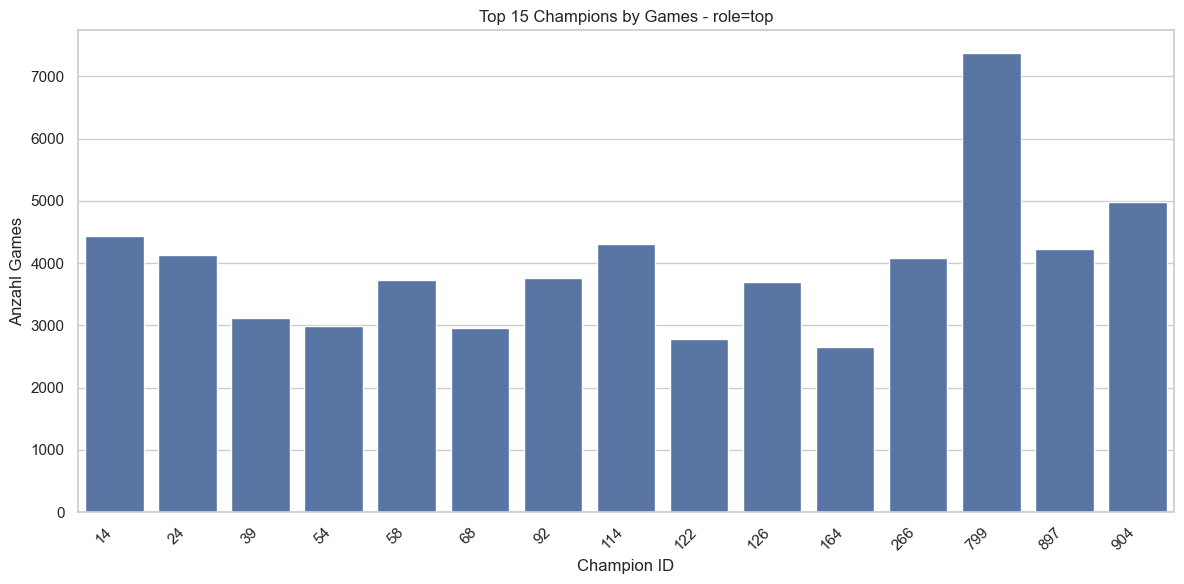

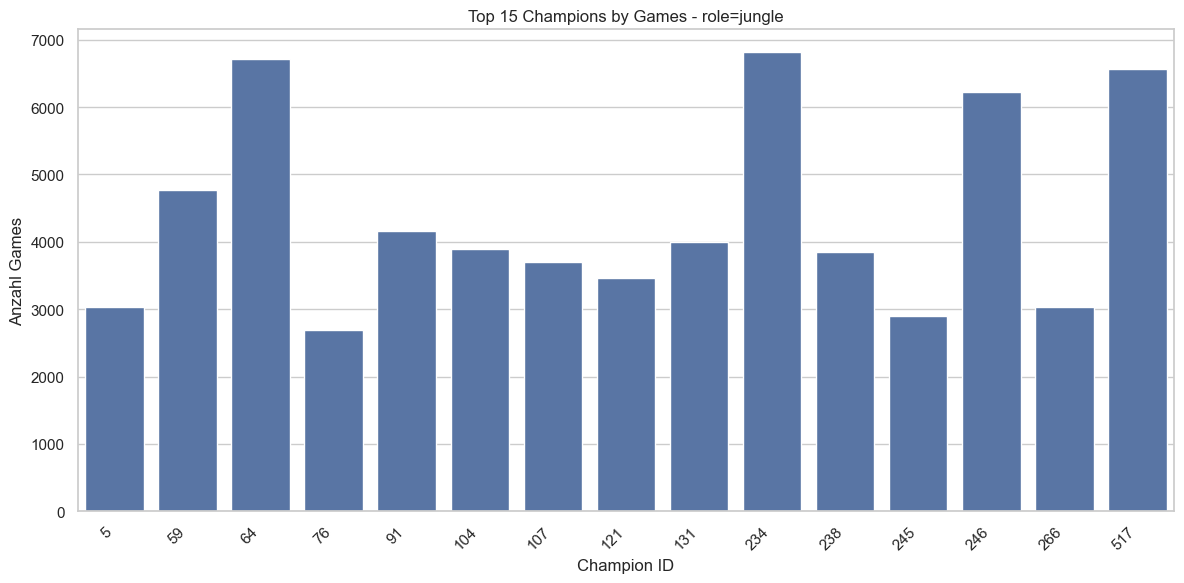

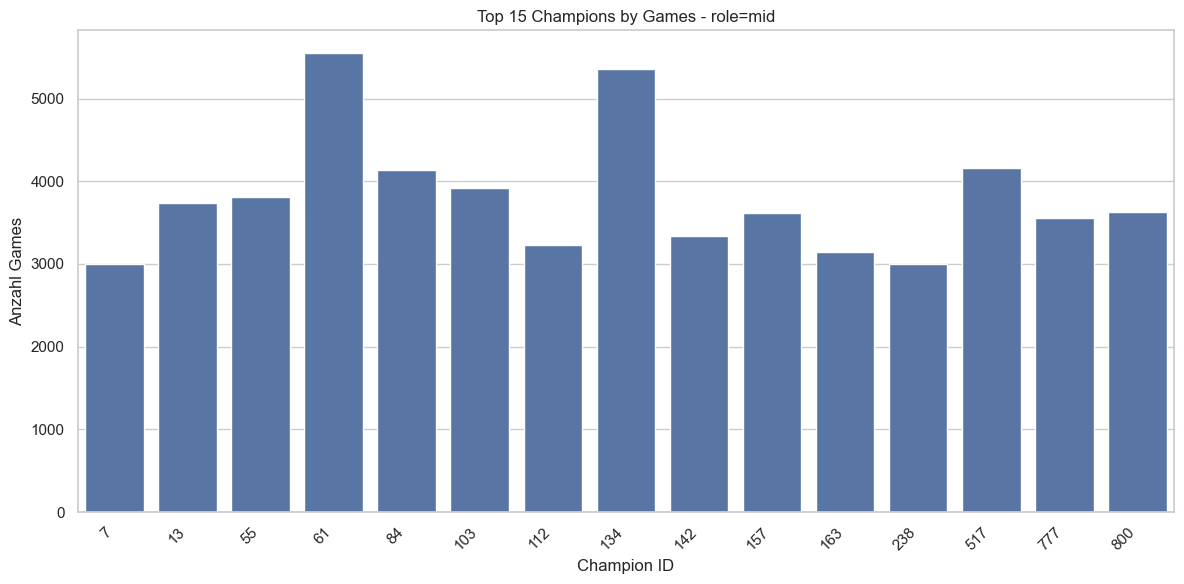

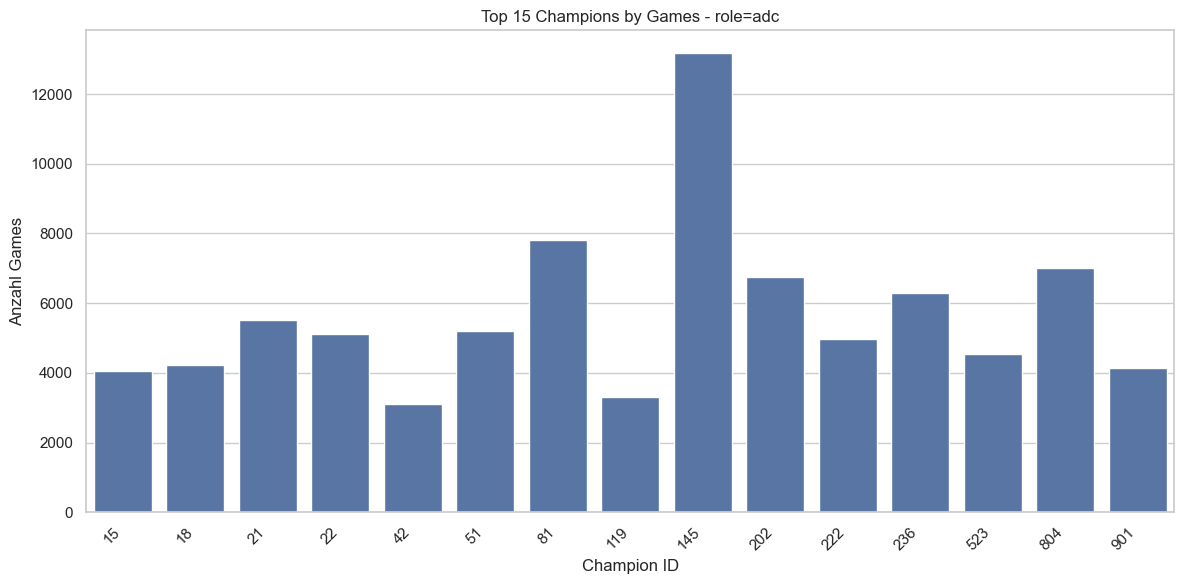

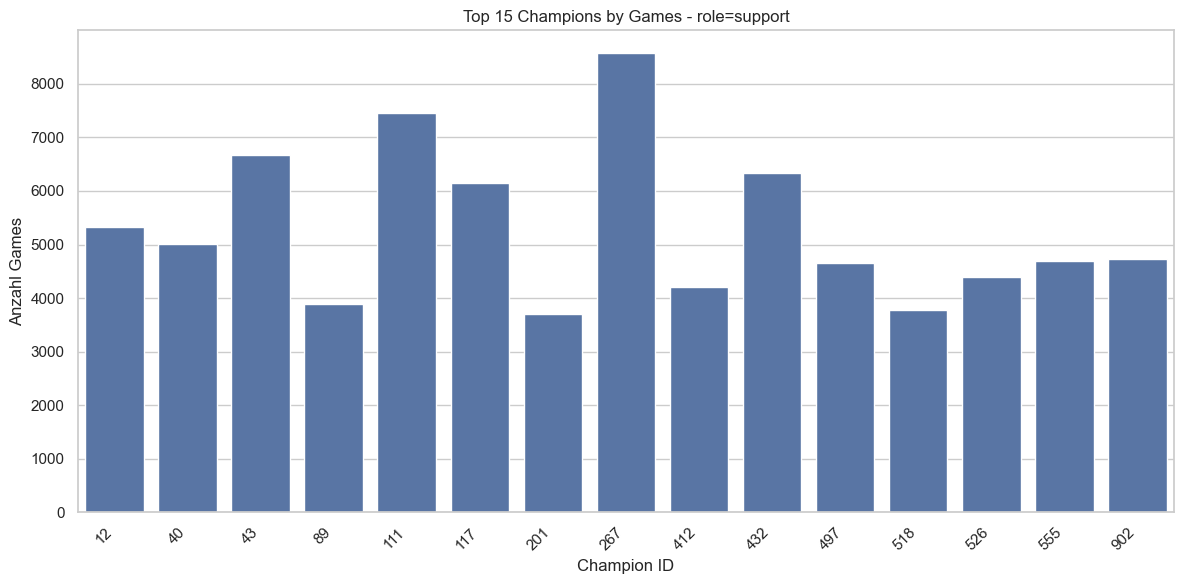

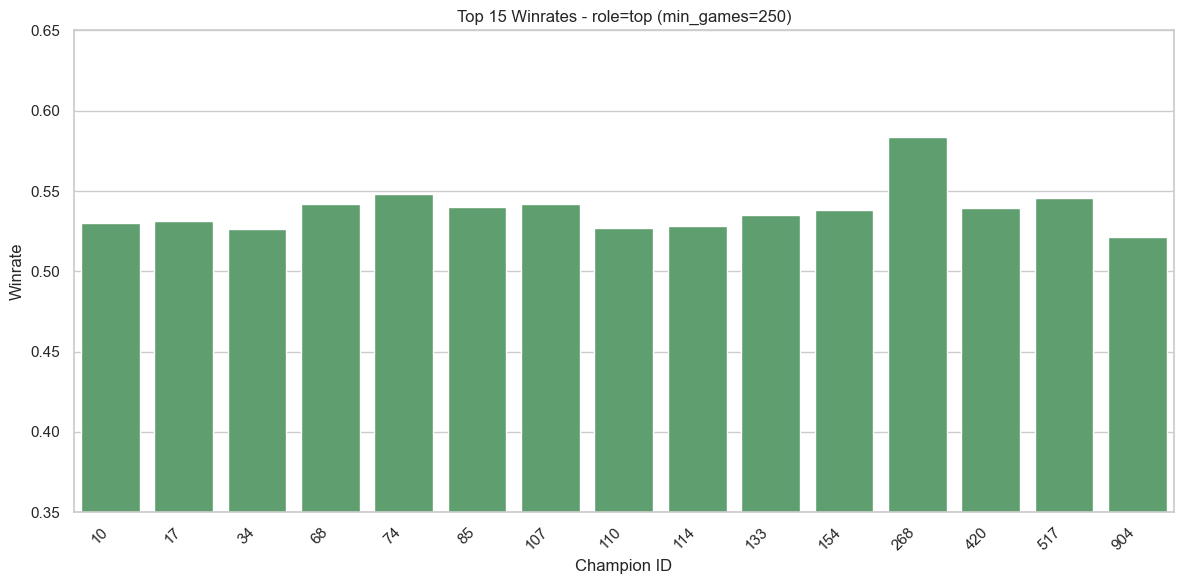

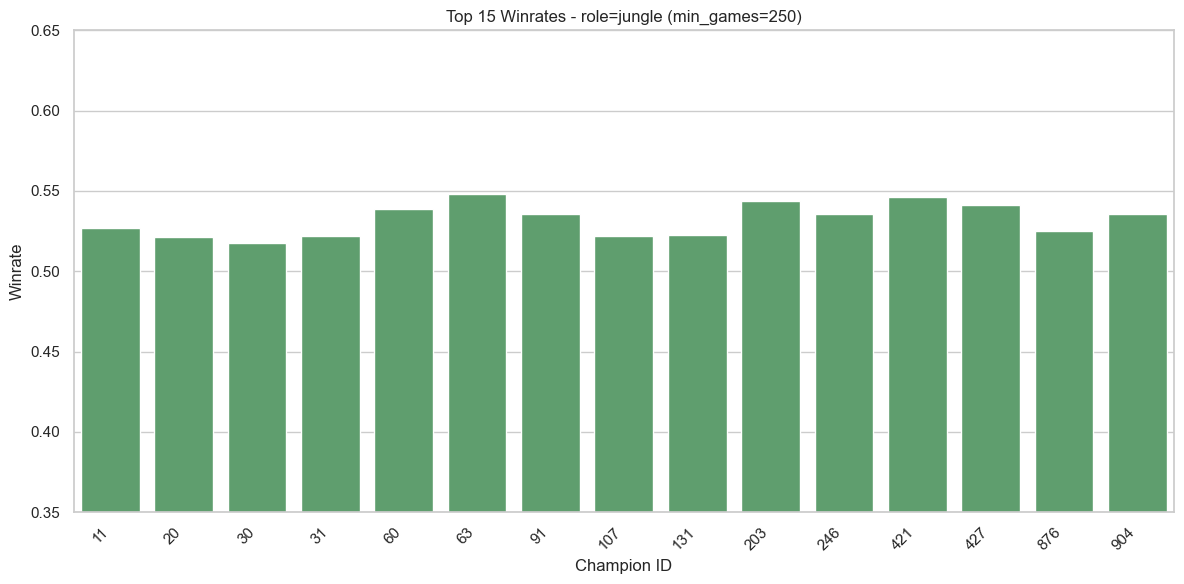

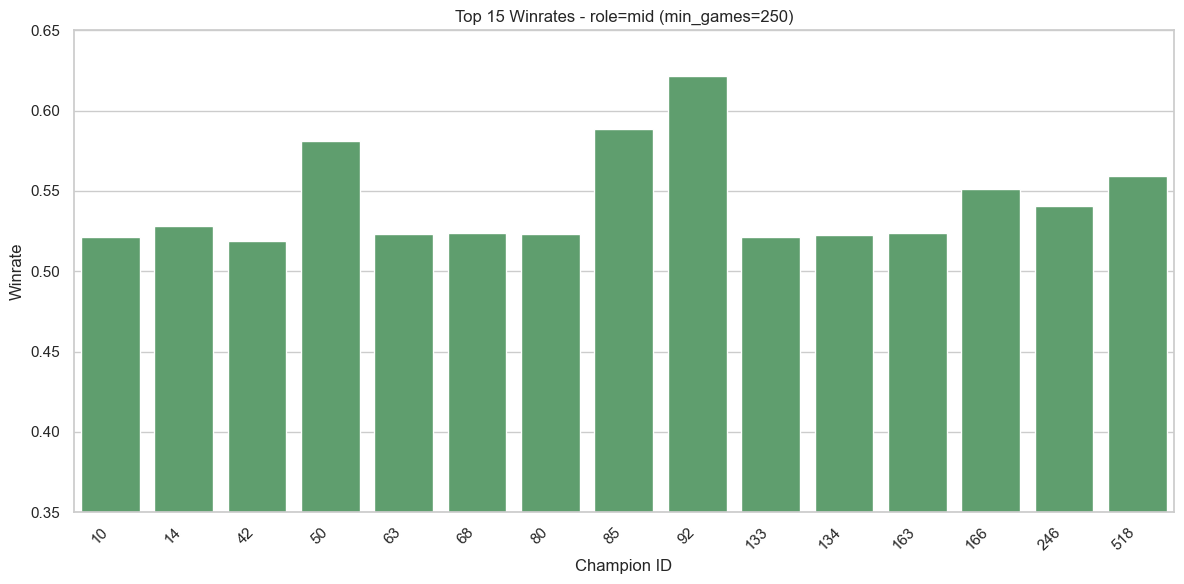

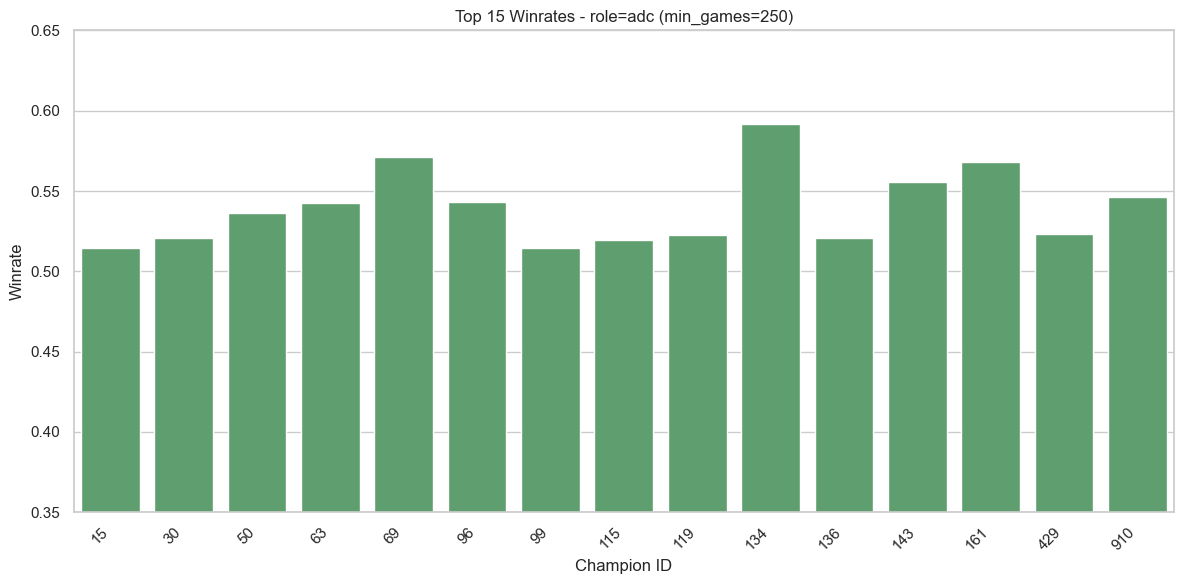

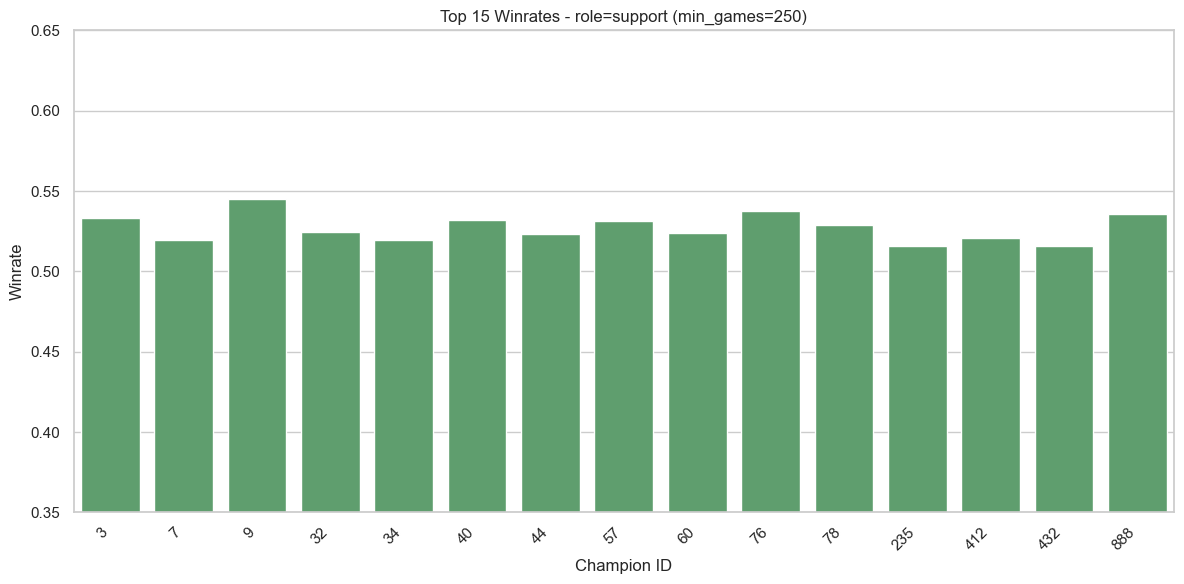

In [64]:
def plot_top_champs_by_games(role_stats: pd.DataFrame, role: str, top_n: int = 15):
    df = role_stats[role_stats["role"] == role].sort_values("games", ascending=False).head(top_n)
    plt.figure(figsize=(12, 6))
    # X-Achse: Champion IDs, Y-Achse: Anzahl Games
    sns.barplot(data=df, x="champion_id", y="games", color="#4c72b0")
    plt.title(f"Top {top_n} Champions by Games - role={role}")
    plt.xlabel("Champion ID")
    plt.ylabel("Anzahl Games")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

def plot_top_champs_by_winrate(role_stats: pd.DataFrame, role: str, min_games: int = 200, top_n: int = 15):
    df = role_stats[(role_stats["role"] == role) & (role_stats["games"] >= min_games)].copy()
    df = df.sort_values("winrate", ascending=False).head(top_n)
    plt.figure(figsize=(12, 6))
    # Y-Achse: Winrate, X-Achse: Champion IDs
    sns.barplot(data=df, x="champion_id", y="winrate", color="#55a868")
    plt.ylim(0.35, 0.65)
    plt.title(f"Top {top_n} Winrates - role={role} (min_games={min_games})")
    plt.xlabel("Champion ID")
    plt.ylabel("Winrate")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

for r in POSITIONS:
    plot_top_champs_by_games(role_stats, r, top_n=15)

for r in POSITIONS:
    plot_top_champs_by_winrate(role_stats, r, min_games=250, top_n=15)


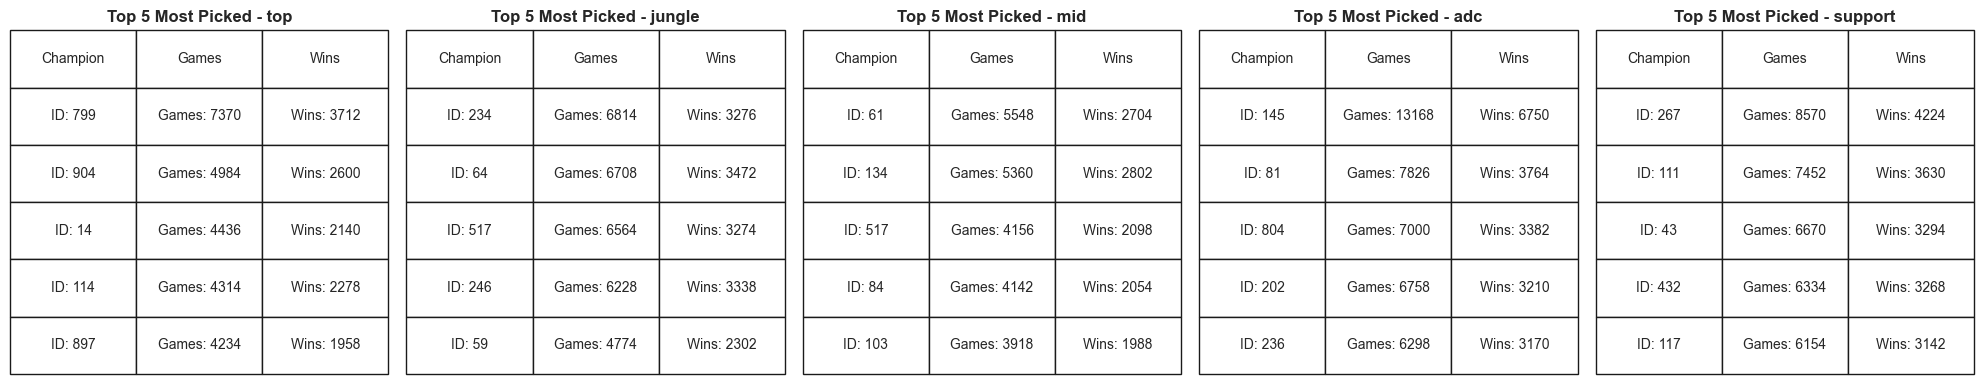

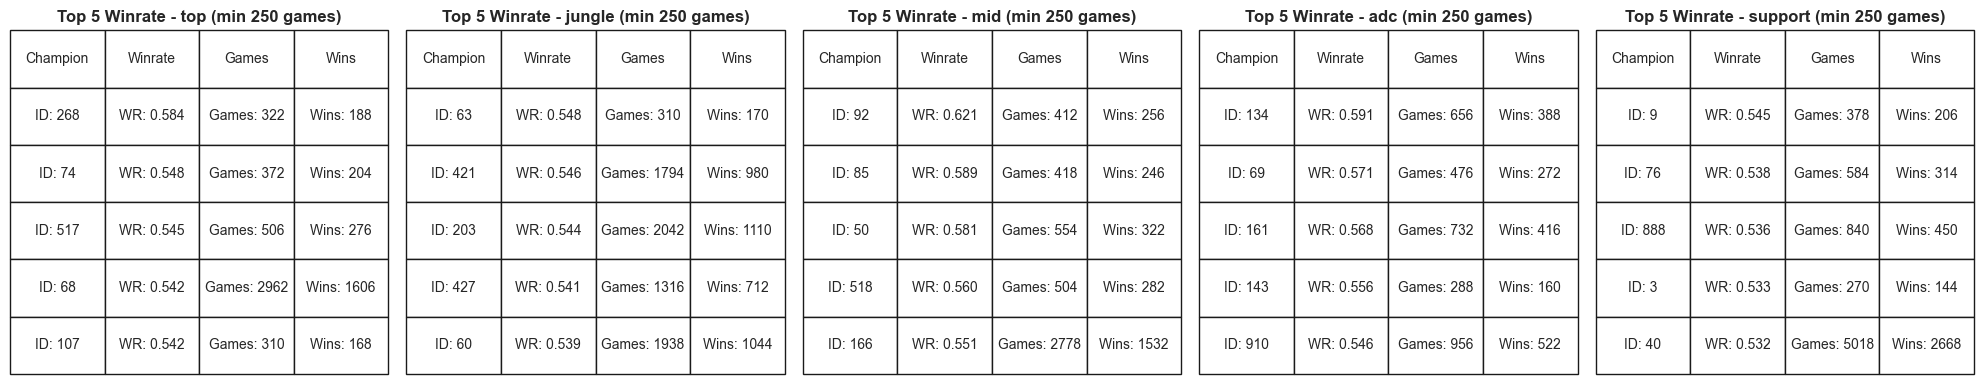

In [65]:
# Raster 1: Top 5 Most Picked Champions pro Position
def plot_top5_most_picked_grid(role_stats: pd.DataFrame):
    fig, axes = plt.subplots(1, 5, figsize=(20, 4))
    for idx, role in enumerate(POSITIONS):
        df = role_stats[role_stats["role"] == role].sort_values("games", ascending=False).head(5)
        ax = axes[idx]
        
        # Erstelle Tabelle-ähnliche Darstellung
        ax.axis('tight')
        ax.axis('off')
        table_data = []
        for _, row in df.iterrows():
            table_data.append([
                f"ID: {int(row['champion_id'])}",
                f"Games: {int(row['games'])}",
                f"Wins: {int(row['wins'])}"
            ])
        
        table = ax.table(cellText=table_data,
                        colLabels=["Champion", "Games", "Wins"],
                        cellLoc='center',
                        loc='center',
                        bbox=[0, 0, 1, 1])
        table.auto_set_font_size(False)
        table.set_fontsize(10)
        table.scale(1, 2)
        ax.set_title(f"Top 5 Most Picked - {role}", fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

# Raster 2: Top 5 Highest Winrate Champions pro Position
def plot_top5_winrate_grid(role_stats: pd.DataFrame, min_games: int = 250):
    fig, axes = plt.subplots(1, 5, figsize=(20, 4))
    for idx, role in enumerate(POSITIONS):
        df = role_stats[(role_stats["role"] == role) & (role_stats["games"] >= min_games)].copy()
        df = df.sort_values("winrate", ascending=False).head(5)
        ax = axes[idx]
        
        # Erstelle Tabelle-ähnliche Darstellung
        ax.axis('tight')
        ax.axis('off')
        table_data = []
        for _, row in df.iterrows():
            table_data.append([
                f"ID: {int(row['champion_id'])}",
                f"WR: {row['winrate']:.3f}",
                f"Games: {int(row['games'])}",
                f"Wins: {int(row['wins'])}"
            ])
        
        table = ax.table(cellText=table_data,
                        colLabels=["Champion", "Winrate", "Games", "Wins"],
                        cellLoc='center',
                        loc='center',
                        bbox=[0, 0, 1, 1])
        table.auto_set_font_size(False)
        table.set_fontsize(10)
        table.scale(1, 2)
        ax.set_title(f"Top 5 Winrate - {role} (min {min_games} games)", fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

# Zeige beide Raster
plot_top5_most_picked_grid(role_stats)
plot_top5_winrate_grid(role_stats, min_games=250)


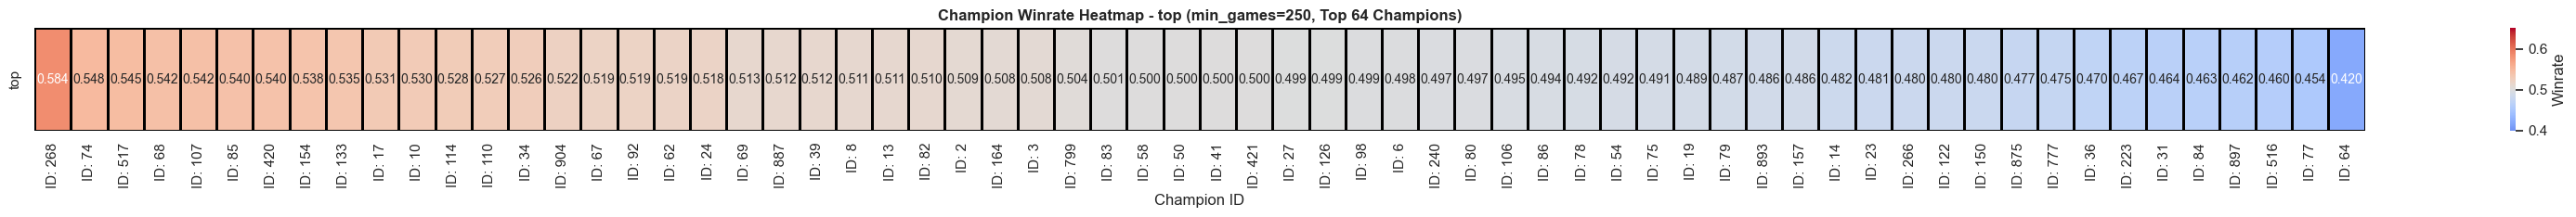

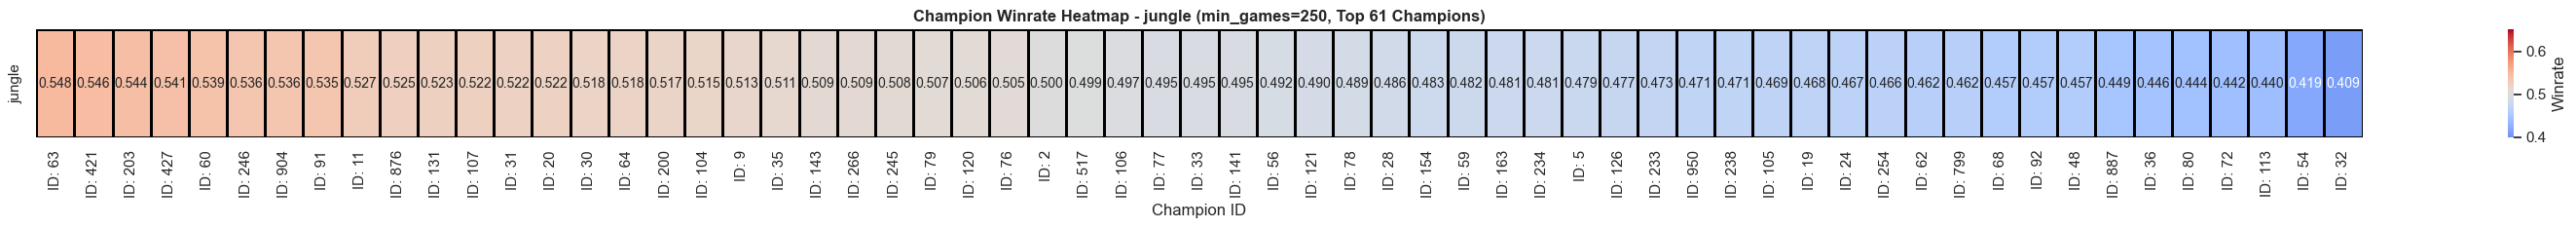

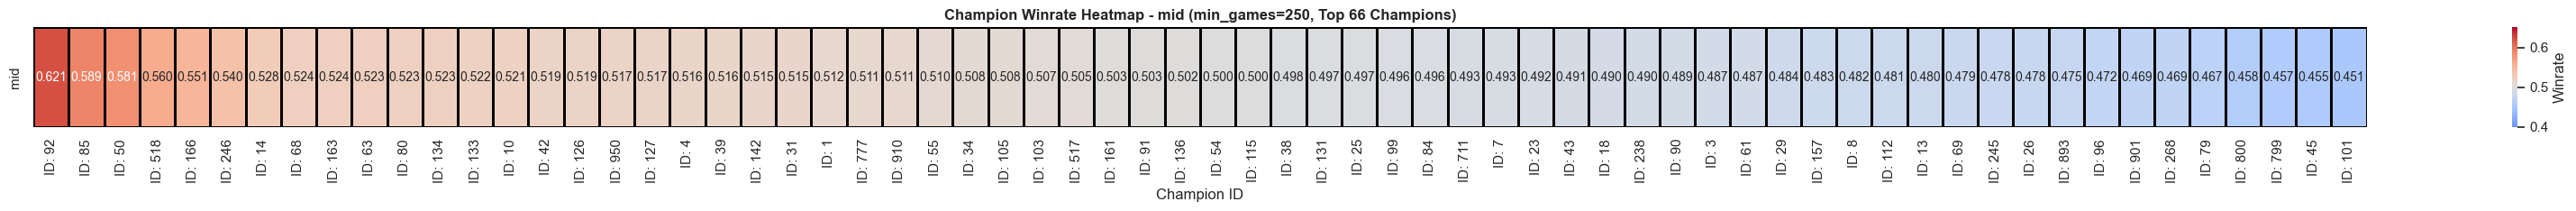

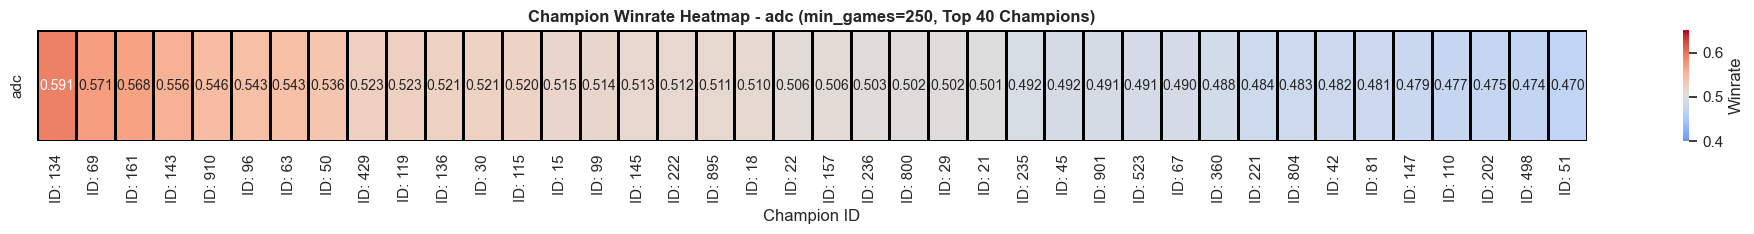

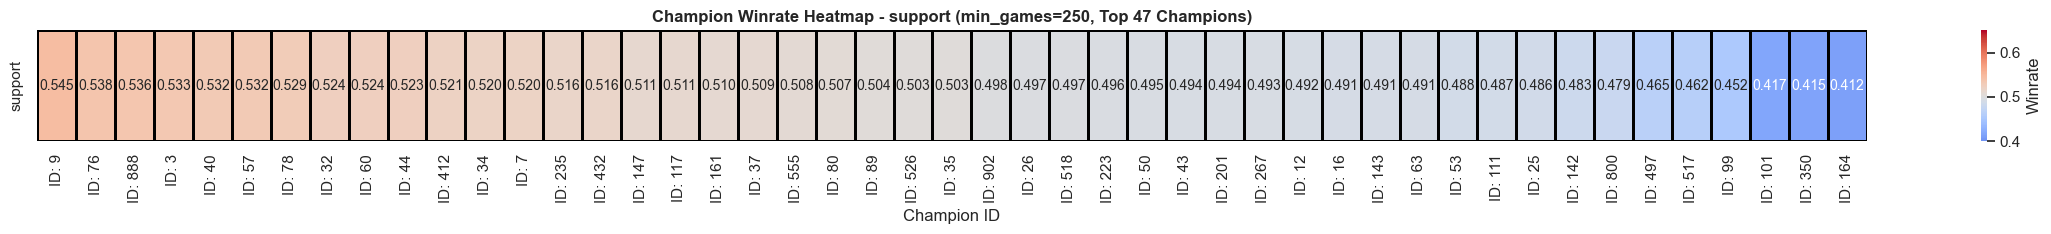

In [66]:
def plot_role_champ_winrate_heatmap_per_position(role_stats: pd.DataFrame, min_games: int = 250):
    """Erstellt eine Heatmap pro Position mit klaren Trennern zwischen Champions."""
    # Einheitliche Scale für alle Positionen
    vmin, vmax = 0.40, 0.65
    
    for role in POSITIONS:
        df = role_stats[(role_stats["role"] == role) & (role_stats["games"] >= min_games)].copy()
        df = df.sort_values("winrate", ascending=False)
        
        if len(df) == 0:
            print(f"[WARN] Keine Champions für {role} mit min_games={min_games}")
            continue
        
        # Erstelle Heatmap-Daten: Jede Zeile = ein Champion
        heatmap_data = df[["winrate"]].T  # Transponiert: eine Zeile mit Winrates
        
        # Größere Felder: mehr Platz pro Champion (0.5 statt 0.3) und höhere Figur
        plt.figure(figsize=(max(10, len(df) * 0.5), 2.5))
        
        # Erstelle Heatmap mit schwarzen Trennern, einheitlicher Scale
        sns.heatmap(heatmap_data, 
                   cmap="coolwarm", 
                   center=0.5,
                   vmin=vmin,  # Einheitliche Min-Scale
                   vmax=vmax,  # Einheitliche Max-Scale
                   annot=True,
                   fmt=".3f",
                   annot_kws={"size": 10},  # Größere Schrift für Zahlen
                   cbar_kws={"label": "Winrate"},
                   linewidths=1,  # Schwarze Linien zwischen Zellen
                   linecolor='black',
                   xticklabels=[f"ID: {int(cid)}" for cid in df["champion_id"].values],
                   yticklabels=[role])
        
        plt.title(f"Champion Winrate Heatmap - {role} (min_games={min_games}, Top {len(df)} Champions)", 
                 fontsize=12, fontweight='bold')
        plt.xlabel("Champion ID")
        plt.ylabel("")
        plt.tight_layout()
        plt.show()

plot_role_champ_winrate_heatmap_per_position(role_stats, min_games=250)


## Modell-Analyse (Confusion Matrix, Report, Feature Importance)

**Was macht dieser Abschnitt?**
- Lädt die trainierten Modelle aus `models/` (Random Forest, XGBoost, Neural Network)
- Erstellt den **gleichen Test-Split** wie beim Training (GroupShuffleSplit, 15% Test, random_state=42)
- **WICHTIG:** Alle Modelle bekommen **exakt die gleichen Train/Val/Test Splits** (gleicher random_state=42)
  - Training: 70% (41532 Matches)
  - Validation: 15% (8900 Matches)  
  - Test: 15% (8902 Matches)
- Evaluiert jedes Modell auf dem Test-Set
- Erstellt für jedes Modell:
  - **Confusion Matrix** (Heatmap): Zeigt, wie oft das Modell richtig/falsch vorhersagt
  - **Classification Report**: Precision, Recall, F1-Score
  - **Feature Importances**: Welche Features sind am wichtigsten
    - **Random Forest & XGBoost:** direkte `feature_importances_` (wie oft ein Feature für Splits verwendet wurde)
    - **Neural Network:** Gewichte der ersten Schicht (Layer 1) - **Warum anders?**
      - Neural Networks haben keine direkten `feature_importances_` wie Tree-Modelle
      - Stattdessen nutzen wir die **Gewichte der ersten Hidden Layer** (`coefs_[0]`)
      - Diese zeigen, wie stark jedes Input-Feature mit den Hidden Neurons verbunden ist
      - Wir nehmen den **absoluten Durchschnitt** über alle Hidden Neurons als "Importance"
      - Das ist eine Approximation - nicht perfekt, aber zeigt trotzdem welche Features wichtig sind

**Warum gibt es `team2_top_winrate` wenn wir schon `team2_top` (Champion ID) haben?**
- `team2_top` = Champion ID (z.B. 15, 18, 21) - **kategorisches Feature**
- `team2_top_winrate` = historische Winrate dieses Champions (z.B. 0.52) - **numerisches Feature**
- **Warum beide?** Das Modell könnte theoretisch aus der ID lernen, aber:
  - **Champion IDs sind kategorisch** - Tree-Modelle müssen viele Splits lernen um Muster zu erkennen
  - **Winrate ist aggregiert** - gibt dem Modell sofort Signal: "Dieser Champion gewinnt im Schnitt 52%"
  - **Kein Cheating:** Winrate wird nur aus Trainingsdaten berechnet (kein Leakage vom Test-Set)
  - **Gängige Praxis:** Feature Engineering - aus rohen Daten (IDs) abgeleitete Features (Stats) erstellen
  - Das Modell nutzt beides: ID für spezifische Muster, Winrate für schnelle Generalisierung



In [67]:
# ============================================================================
# HILFSFUNKTIONEN FÜR MODELL-EVALUATION
# ============================================================================
# Diese Funktionen werden in Cell 10 verwendet, um alle 3 Modelle zu evaluieren:
# - make_test_split() → erstellt Test-Split (gleicher wie beim Training)
# - load_model_bundle() → lädt Modell + Features + Scaler
# - build_X() → bereitet Test-Daten für Modell vor
# - plot_confusion() → erstellt Confusion Matrix
# - plot_feature_importance() → zeigt wichtigste Features
# ============================================================================

def make_groups(df: pd.DataFrame) -> pd.Series:
    match_ids = df["match_id"].astype(str)
    return match_ids.str.replace("_mirrored", "", regex=False)


def make_test_split(df: pd.DataFrame, test_size: float = 0.15, seed: int = 42):
    groups = make_groups(df)
    y = df["target"]
    gss = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=seed)
    train_val_idx, test_idx = next(gss.split(df, y, groups))
    return train_val_idx, test_idx


def load_model_bundle(model_name: str):
    model_path = MODELS_DIR / f"{model_name}.pkl"
    feat_path = MODELS_DIR / f"{model_name}_features.txt"
    scaler_path = MODELS_DIR / "neural_network_scaler.pkl"

    model = joblib.load(model_path)
    features = [l.strip() for l in feat_path.read_text(encoding="utf-8").splitlines() if l.strip()]
    scaler = joblib.load(scaler_path) if (model_name == "neural_network" and scaler_path.exists()) else None
    return model, features, scaler


def build_X(df: pd.DataFrame, features: list[str], model_name: str) -> pd.DataFrame:
    X = df[features].copy()

    # Champion ID cols
    champ_cols = [
        c for c in features
        if any(p in c for p in POSITIONS)
        and "winrate" not in c
        and "matchup" not in c
        and "synergy" not in c
        and "diff" not in c
    ]
    for c in champ_cols:
        base = X[c].fillna(-1).astype(int)
        if model_name == "xgboost":
            X[c] = base.astype("category")
        else:
            X[c] = base

    # numeric features
    winrate_cols = [c for c in features if "winrate" in c]
    for c in winrate_cols:
        X[c] = X[c].fillna(0.5).astype(float)

    extra_numeric_cols = [c for c in features if ("matchup" in c) or ("synergy" in c) or c.endswith("_diff")]
    for c in extra_numeric_cols:
        X[c] = X[c].fillna(0.0).astype(float)

    return X


def plot_confusion(y_true, y_pred, title: str):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(4.2, 3.6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(title)
    plt.xlabel("Pred")
    plt.ylabel("True")
    plt.tight_layout()
    plt.show()


def plot_feature_importance(model, features: list[str], title: str, top_n: int = 20):
    # Random Forest & XGBoost haben feature_importances_
    if hasattr(model, "feature_importances_"):
        vals = list(getattr(model, "feature_importances_"))
        imp = pd.DataFrame({"feature": features, "importance": vals}).sort_values("importance", ascending=False).head(top_n)
        plt.figure(figsize=(9, 6))
        sns.barplot(data=imp, y="feature", x="importance", color="#4c72b0")
        plt.title(title)
        plt.tight_layout()
        plt.show()
    # Neural Network (MLPClassifier) hat keine feature_importances_, aber wir können die Gewichte der ersten Schicht visualisieren
    elif hasattr(model, "coefs_") and len(model.coefs_) > 0:
        # Erste Schicht Gewichte: coefs_[0] hat Shape (n_features, n_hidden_neurons)
        # Wir nehmen den absoluten Durchschnitt über alle Hidden Neurons
        weights = np.abs(model.coefs_[0]).mean(axis=1)
        imp = pd.DataFrame({"feature": features, "importance": weights}).sort_values("importance", ascending=False).head(top_n)
        plt.figure(figsize=(9, 6))
        sns.barplot(data=imp, y="feature", x="importance", color="#4c72b0")
        plt.title(f"{title} (aus Layer 1 Gewichten)")
        plt.xlabel("Average Absolute Weight")
        plt.tight_layout()
        plt.show()
    else:
        print(f"[INFO] Keine Feature Importance verfügbar für {title}")
        print("      (Neural Networks haben keine direkten feature_importances_)")

# Use richest dataset so all feature-columns are present
if CHAMPSELECT_DATASET.exists():
    df_eval = pd.read_csv(CHAMPSELECT_DATASET)
elif WINRATES_DATASET.exists():
    df_eval = pd.read_csv(WINRATES_DATASET)
else:
    df_eval = df_raw.copy()

# Erstelle Test-Split für Model-Evaluation
# WICHTIG: Nutzt den gleichen random_state=42 wie beim Training
# Alle Modelle werden auf exakt den gleichen Test-Matches evaluiert
train_val_idx, test_idx = make_test_split(df_eval)
df_test = df_eval.iloc[test_idx].copy()
y_test = df_test["target"].astype(int)

print("Test-Set für Model-Evaluation:", len(df_test), "Matches")
print("(Dieser Split wird für alle 3 Modelle verwendet)")


Test-Set für Model-Evaluation: 8902 Matches
(Dieser Split wird für alle 3 Modelle verwendet)



random_forest accuracy: 52.52%
              precision    recall  f1-score   support

           0       0.53      0.52      0.52      4451
           1       0.53      0.53      0.53      4451

    accuracy                           0.53      8902
   macro avg       0.53      0.53      0.53      8902
weighted avg       0.53      0.53      0.53      8902



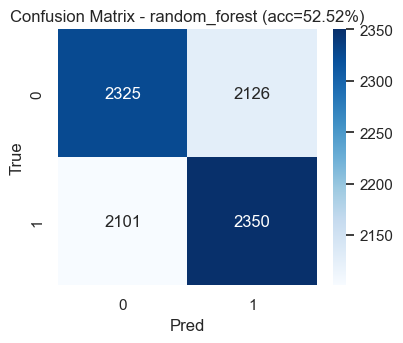

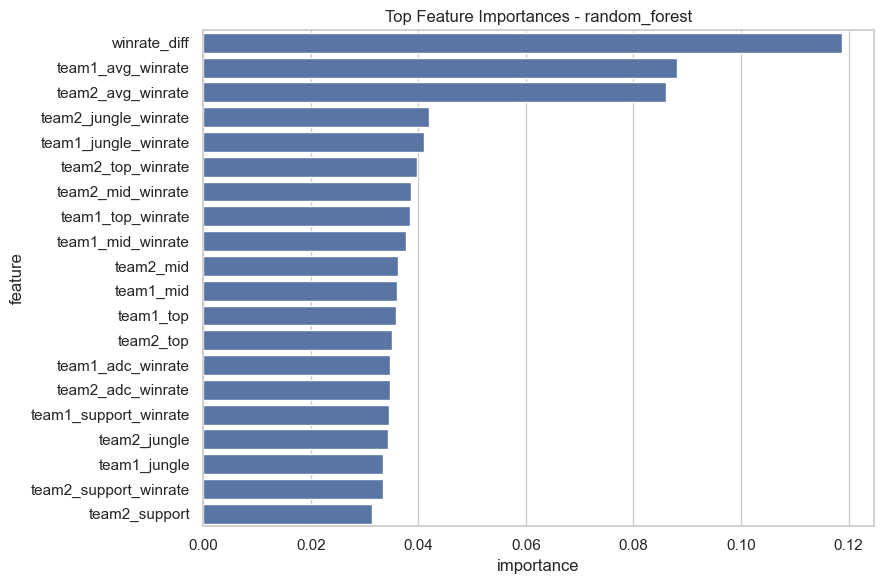


xgboost accuracy: 52.68%
              precision    recall  f1-score   support

           0       0.53      0.53      0.53      4451
           1       0.53      0.52      0.53      4451

    accuracy                           0.53      8902
   macro avg       0.53      0.53      0.53      8902
weighted avg       0.53      0.53      0.53      8902



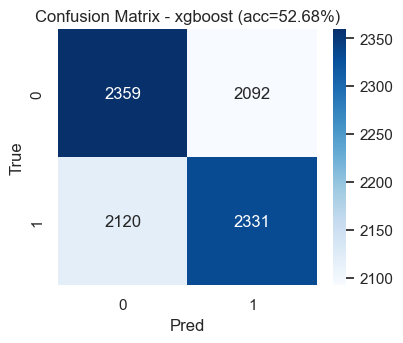

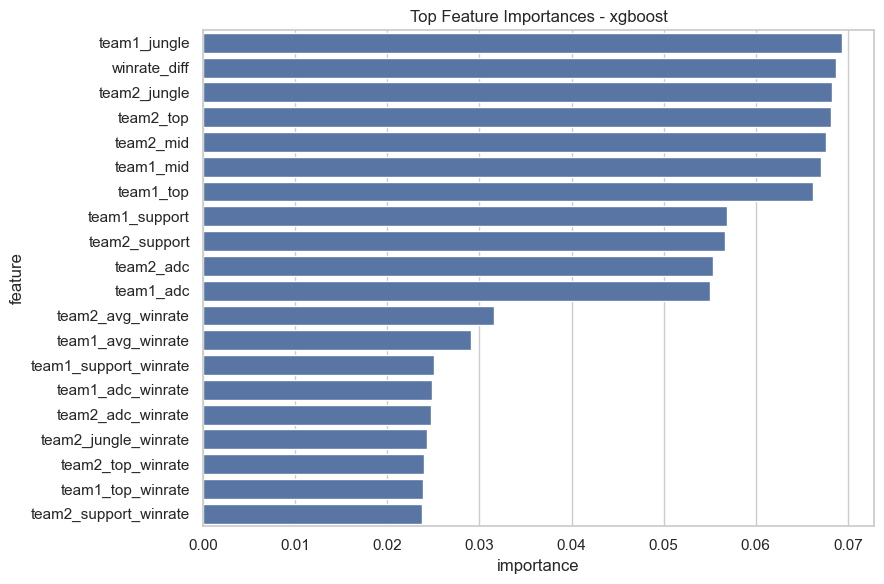


neural_network accuracy: 51.88%
              precision    recall  f1-score   support

           0       0.52      0.52      0.52      4451
           1       0.52      0.52      0.52      4451

    accuracy                           0.52      8902
   macro avg       0.52      0.52      0.52      8902
weighted avg       0.52      0.52      0.52      8902



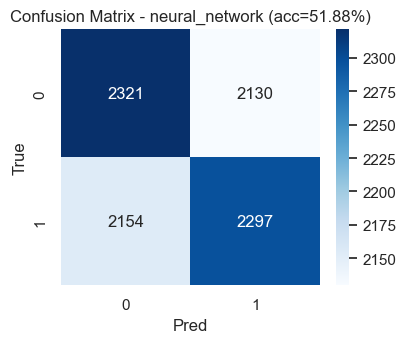

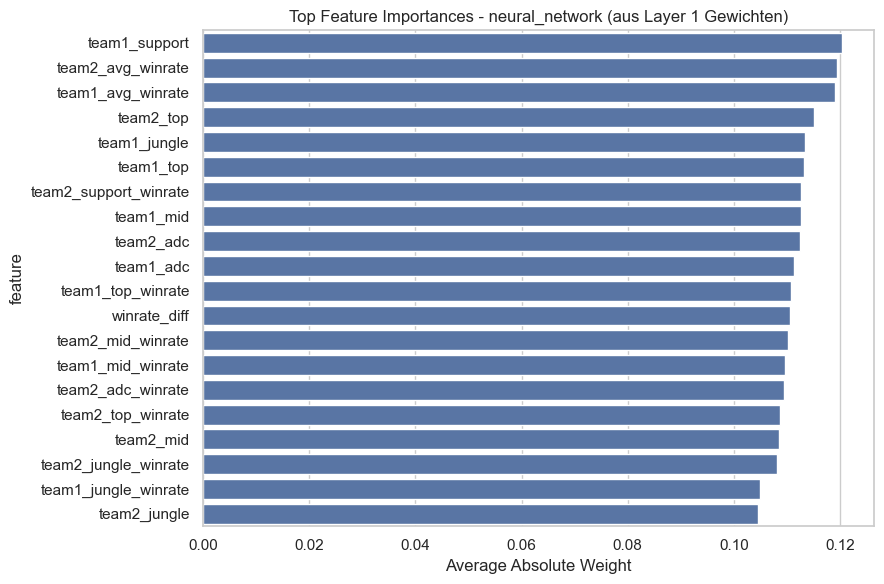

In [68]:
for model_name in ["random_forest", "xgboost", "neural_network"]:
    model_path = MODELS_DIR / f"{model_name}.pkl"
    feat_path = MODELS_DIR / f"{model_name}_features.txt"
    if not model_path.exists() or not feat_path.exists():
        print(f"[WARN] missing model or features for {model_name}")
        continue

    model, feats, scaler = load_model_bundle(model_name)
    X_test = build_X(df_test, feats, model_name)

    if model_name == "neural_network" and scaler is not None:
        X_scaled = scaler.transform(X_test)
        y_pred = model.predict(X_scaled)
    else:
        y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    print("\n" + "=" * 70)
    print(model_name, "accuracy:", f"{acc*100:.2f}%")
    print(classification_report(y_test, y_pred))

    plot_confusion(y_test, y_pred, title=f"Confusion Matrix - {model_name} (acc={acc*100:.2f}%)")
    plot_feature_importance(model, feats, title=f"Top Feature Importances - {model_name}")
